# 📊 EDA for Disease Medication Details with Timings

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("..//backend/Training/MasterData/disease_medication_details_with_timings.csv")
print("Dataset Uploaded Sucessfully!")

Dataset Uploaded Sucessfully!


## 🔎 Dataset Overview

In [3]:
print("🔹 Dataset Shape:", df.shape)
display(df.head())

🔹 Dataset Shape: (185, 4)


,Disease,Medicine Name,Dosage,Timing
0,Fungal infection,Candid Multi-Benefit Skin Cream,Apply twice daily,Apply twice daily
1,Fungal infection,Fluconazole tablet usp,150 mg once weekly,Once daily
2,Fungal infection,Terbinafine,To be prescribed,To be prescribed
3,Fungal infection,Topical Clotrimazole,To be prescribed,To be prescribed
4,Fungal infection,Ketoconazole,To be prescribed,To be prescribed


In [4]:
print("\n🔹 Info:")
df.info()


🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Disease        185 non-null    object
 1   Medicine Name  185 non-null    object
 2   Dosage         185 non-null    object
 3   Timing         185 non-null    object
dtypes: object(4)
memory usage: 5.9+ KB


In [5]:
print("\n🔹 Column Names:", df.columns.tolist())
print("\n🔹 Data Types:\n", df.dtypes)
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Column Names: ['Disease', 'Medicine Name', 'Dosage', 'Timing']

🔹 Data Types:
 Disease          object
Medicine Name    object
Dosage           object
Timing           object
dtype: object

🔹 Missing Values:
 Disease          0
Medicine Name    0
Dosage           0
Timing           0
dtype: int64

🔹 Duplicate Rows: 0


In [6]:
# Unique values per column
print("\n🔹 Unique Value Counts:")
print(df.nunique())


🔹 Unique Value Counts:
Disease           37
Medicine Name    148
Dosage            12
Timing            13
dtype: int64


In [7]:
print("\n🔹Statistics:")
display(df.describe(include="all").transpose())


🔹Statistics:


,count,unique,top,freq
Disease,185,37,Fungal infection,5
Medicine Name,185,148,IV fluids,10
Dosage,185,12,To be prescribed,167
Timing,185,13,To be prescribed,167



=== Analysis ===


C:\Users\hp\AppData\Local\Temp\ipykernel_4252\3027182353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


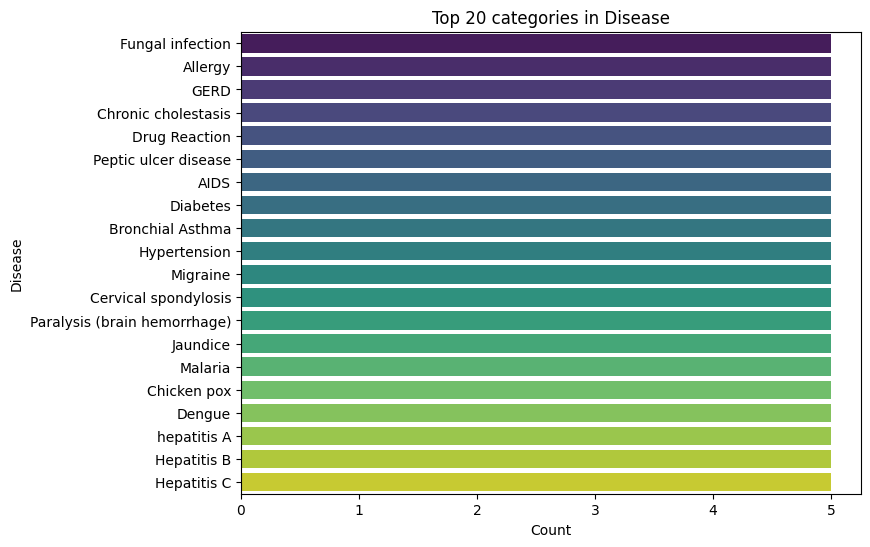

C:\Users\hp\AppData\Local\Temp\ipykernel_4252\3027182353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


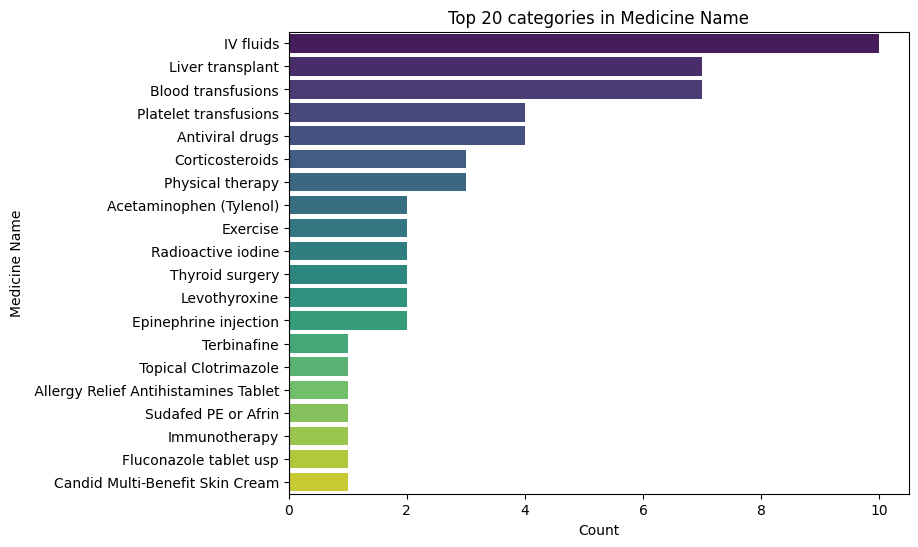

C:\Users\hp\AppData\Local\Temp\ipykernel_4252\3027182353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


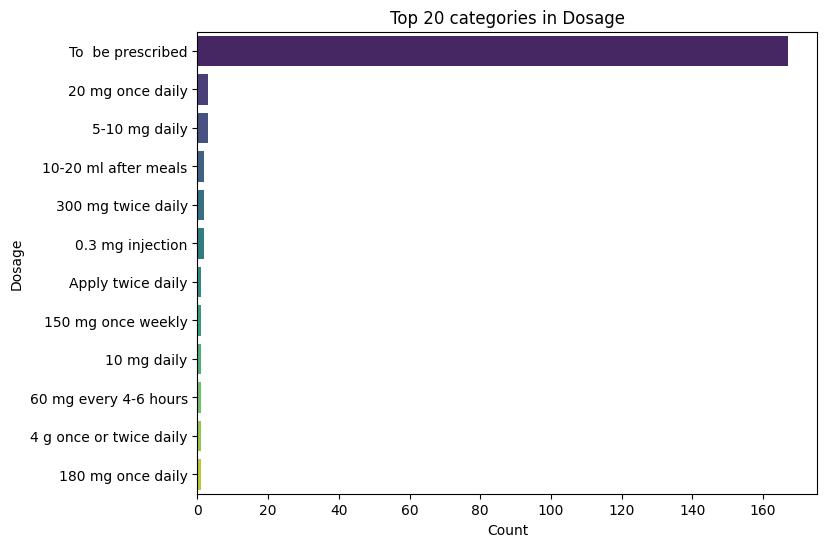

C:\Users\hp\AppData\Local\Temp\ipykernel_4252\3027182353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


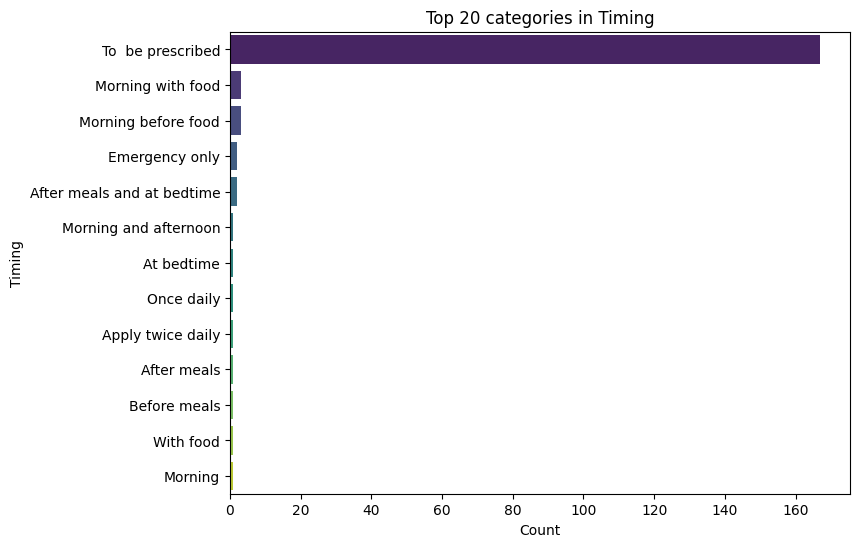

In [8]:
print("\n=== Analysis ===")

for col in df.columns:
    plt.figure(figsize=(8,6))
    if df[col].dtype == 'object':
        top_vals = df[col].value_counts().head(20)
        sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")
        plt.title(f"Top 20 categories in {col}")
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.show()
    else:
        sns.histplot(df[col], kde=True, bins=30, color="royalblue")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

In [9]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,6))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

In [10]:
# Crosstab for categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) >= 2:
    for i in range(len(cat_cols)-1):
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[i+1]])
        print(f"\n🔹 Crosstab between {cat_cols[i]} and {cat_cols[i+1]}:\n", ct.head())


🔹 Crosstab between Disease and Medicine Name:
 Medicine Name                            Allergy Relief Antihistamines Tablet  \
Disease                                                                         
(vertigo) Paroymsal Positional Vertigo                                      0   
AIDS                                                                        0   
Acne                                                                        0   
Alcoholic hepatitis                                                         0   
Allergy                                                                     1   

Medicine Name                            Ibuprofen and Naproxen   Myambutol  \
Disease                                                                       
(vertigo) Paroymsal Positional Vertigo                        0           0   
AIDS                                                          0           0   
Acne                                                          0     


=== Boxplots for Each Feature ===


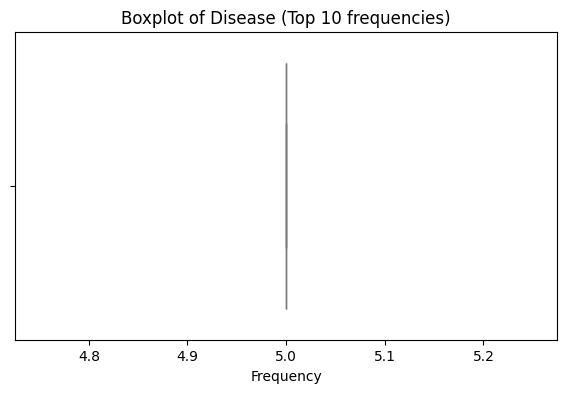

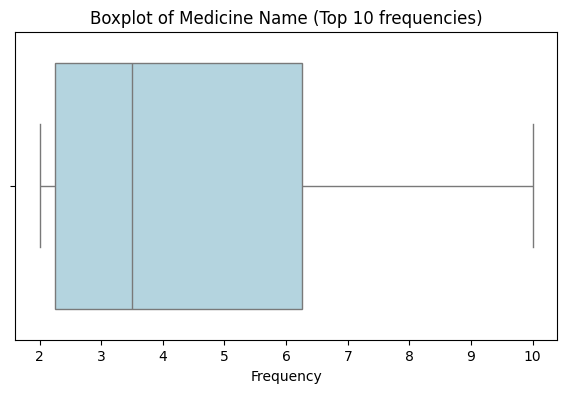

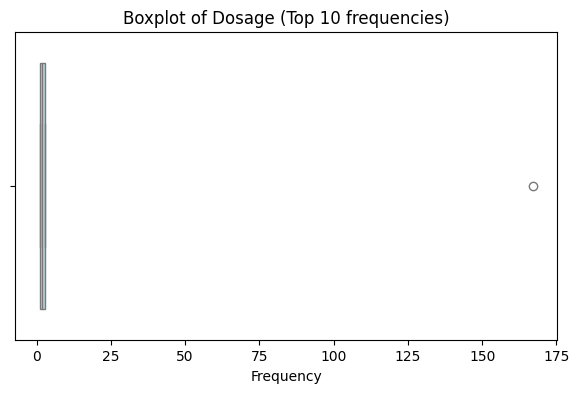

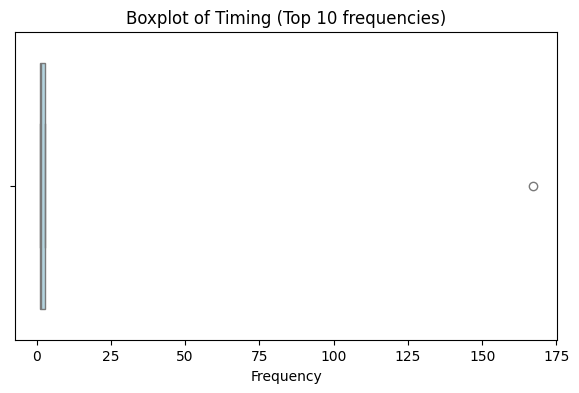

In [11]:
print("\n=== Boxplots for Each Feature ===")

for col in df.columns:
    plt.figure(figsize=(7,4))
    if df[col].dtype != 'object':  # numeric features
        sns.boxplot(x=df[col], color="orange")
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.show()
    else:  # categorical features (frequency counts as boxplot)
        top_vals = df[col].value_counts().head(10)
        sns.boxplot(x=top_vals.values, color="lightblue")
        plt.title(f"Boxplot of {col} (Top 10 frequencies)")
        plt.xlabel("Frequency")
        plt.show()

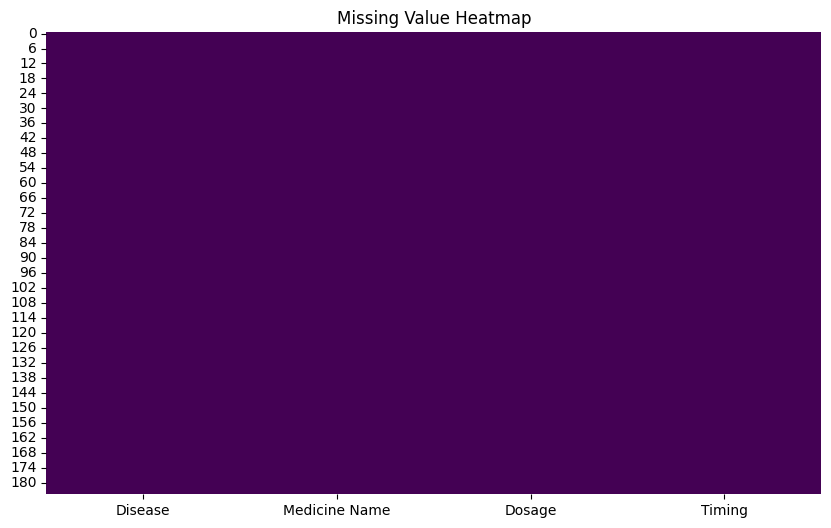

In [12]:
# Missing Data Visualization
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

### EDA Completed Successfully!